# Notebook for analysis

In [1]:
# run the import and install packages.py file 
%run install_packages.py

MIRSI Simulations - Package Dependency Checker

Checking for required packages...
✓ numpy is already installed
✓ astropy is already installed
✓ matplotlib is already installed
✓ photutils is already installed
✓ scipy is already installed

✓ All required packages are already installed!

Setup complete! You can now run the MIRSI simulations.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry 

## DATA FROM 02-030-26

### Zenith

Processing 1500 FITS files from ./data/260203/zenith_dark
Loaded 1500 FITS files from ./data/260203/zenith_dark
Processing 1500 FITS files from ./data/260203/zenith_sky_1
Loaded 1500 FITS files from ./data/260203/zenith_sky_1
Processing 1500 FITS files from ./data/260203/zenith_sky_2
Loaded 1500 FITS files from ./data/260203/zenith_sky_2
Processing 1500 FITS files from ./data/260203/zenith_sky_3
Loaded 1500 FITS files from ./data/260203/zenith_sky_3


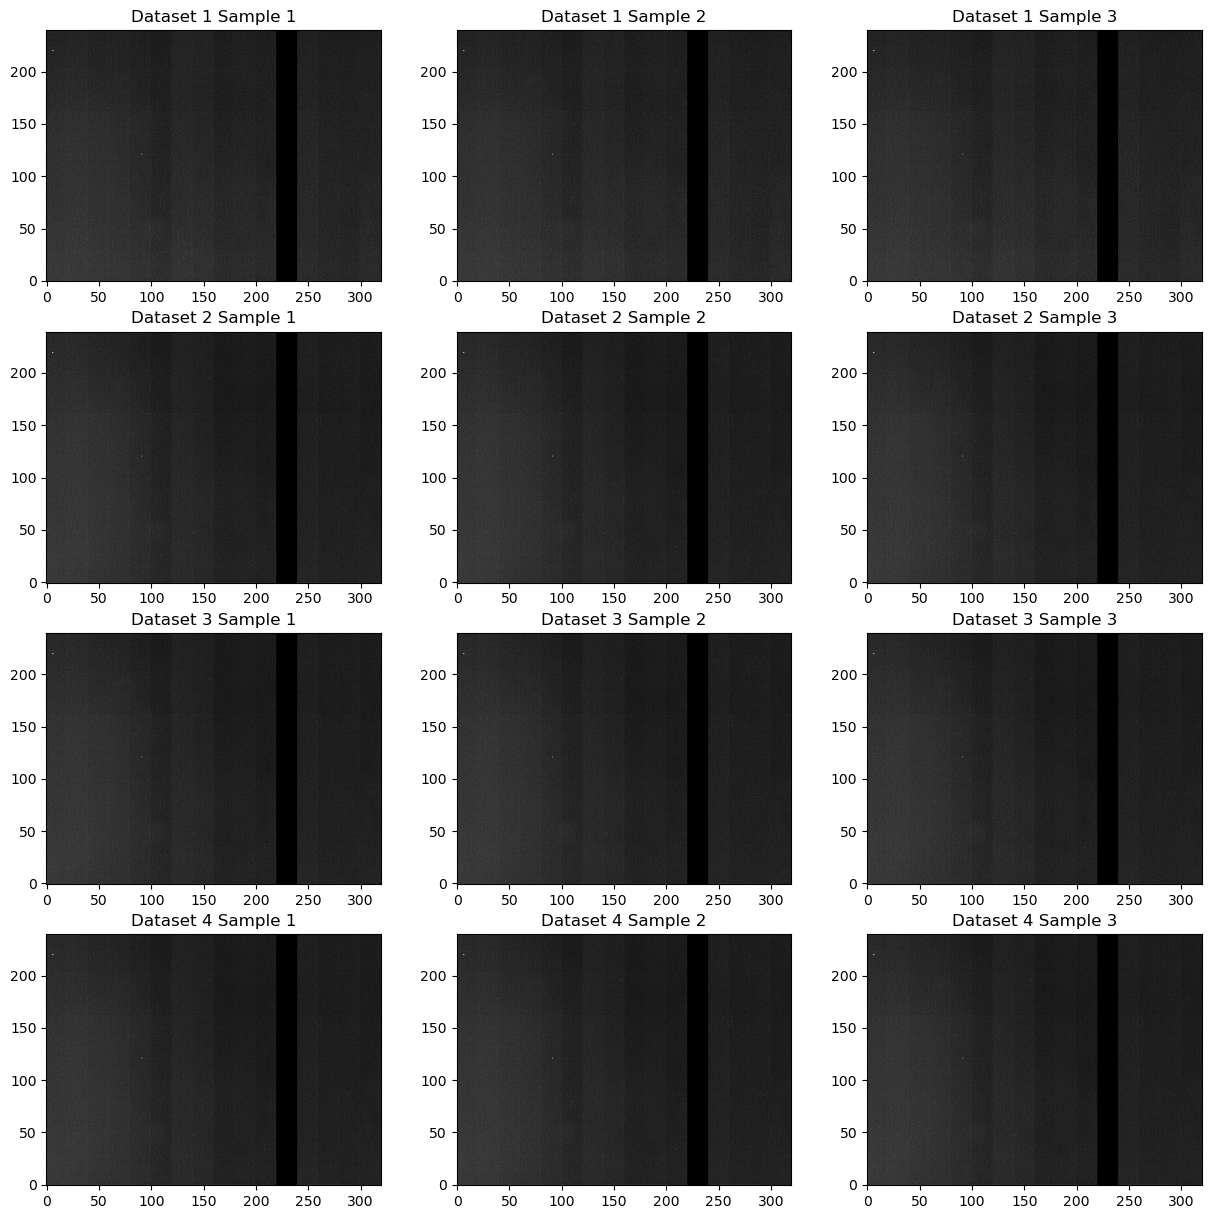

In [3]:
# Read in the data from the fits file 
from test_analysis import read_in_fits
zenith_dark_data = read_in_fits('./data/260203/zenith_dark')
zenith_sky_1_data = read_in_fits('./data/260203/zenith_sky_1')
zenith_sky_2_data = read_in_fits('./data/260203/zenith_sky_2')
zenith_sky_3_data = read_in_fits('./data/260203/zenith_sky_3')
# display three random images from each to make sure it loaded in correctly

list = [zenith_dark_data, zenith_sky_1_data, zenith_sky_2_data, zenith_sky_3_data]
test_fig, test_axs = plt.subplots(len(list), 3, figsize=(15,15))
for i, data in enumerate(list):
    for j in range(3):  # 3 samples per dataset
        test_axs[i, j].imshow(data[np.random.randint(0, data.shape[0])], cmap='gray', origin='lower')
        test_axs[i, j].set_title(f'Dataset {i+1} Sample {j+1}')
plt.show()

Perform aperture photometry in the selected region

In [4]:
from test_analysis import preliminary_analysis
region = (30,80,15)  # Example region (y, x, radius)
TRIM_FRAMES = (200, -1)

# Load another region 
region_2 = (150, 50, 15)

Try the alternative chopping and nodding method

Here, the coadds are the atomic unit - forming dwells. But they should be summed t 


In [5]:
def coadd_to_dwells(raw_cube, n, method="sum", trim=None):
    """
    Convert fast-read raw frames into 'dwell' frames by binning n consecutive frames.

    Parameters
    ----------
    raw_cube : (N, ny, nx) ndarray
        Fast-read frames.
    n : int
        Number of fast frames per dwell (software-emulated dwell / coadd).
    method : {"mean","sum"}
        How to combine frames inside each dwell.
    trim : (i0, i1) or None
        Optional slice on the raw frames before binning.

    Returns
    -------
    dwell_cube : (N_dwell, ny, nx) ndarray
        Coadded dwell frames.
    """
    if trim is not None:
        raw_cube = raw_cube[trim[0]:trim[1]]

    raw_cube = np.asarray(raw_cube)
    if raw_cube.ndim != 3:
        raise ValueError("raw_cube must have shape (N, ny, nx)")

    if n < 1:
        raise ValueError("n must be >= 1")

    N, ny, nx = raw_cube.shape
    Ntrim = (N // n) * n
    if Ntrim < n:
        raise ValueError("Not enough frames to form one dwell.")

    blocks = raw_cube[:Ntrim].reshape(-1, n, ny, nx)

    if method == "mean":
        dwell_cube = blocks.mean(axis=1)
    elif method == "sum":
        dwell_cube = blocks.sum(axis=1)
    else:
        raise ValueError("method must be 'mean' or 'sum'")

    return dwell_cube

In [6]:
zenith_sky_1_coadds = coadd_to_dwells(zenith_sky_1_data, n=1, method="sum", trim=TRIM_FRAMES)

In [7]:
np.shape(zenith_sky_1_data)

(1500, 240, 320)

In [8]:
def chop_demodulate_pairwise(dwell_cube):
    """
    Pairwise demodulation for ABAB... sequence:
        diff[m] = A[m] - B[m]  with A=even dwells, B=odd dwells

    Parameters
    ----------
    dwell_cube : (N_dwell, ny, nx) ndarray

    Returns
    -------
    diff_cube : (N_pairs, ny, nx) ndarray
        One chopped difference image per AB pair.
    """
    dwell_cube = np.asarray(dwell_cube)
    if dwell_cube.ndim != 3:
        raise ValueError("dwell_cube must have shape (N_dwell, ny, nx)")

    N, ny, nx = dwell_cube.shape
    n_pairs = N // 2
    if n_pairs < 1:
        raise ValueError("Need at least 2 dwells (A and B) to form one pair.")

    d2 = dwell_cube[:2 * n_pairs]
    A = d2[0::2]
    B = d2[1::2]
    return A - B

In [9]:
zenith_sky_1_diffs = chop_demodulate_pairwise(zenith_sky_1_data)

In [10]:
np.shape(zenith_sky_1_diffs)

(750, 240, 320)

In [11]:
def dwell_and_chop_frequencies(frame_dt_s, n):
    """
    frame_dt_s: cadence of fast-read frames
    n: frames per dwell

    Returns:
      t_dwell, f_state, f_chop
    where:
      f_state = 1/t_dwell  (A->B state switching rate)
      f_chop  = 1/(2*t_dwell) (full AB cycle rate)
    """
    t_dwell = frame_dt_s * n
    f_state = 1.0 / t_dwell
    f_chop = 1.0 / (2.0 * t_dwell)
    return t_dwell, f_state, f_chop

In [12]:
frame_dt_s=0.0103
freqs = dwell_and_chop_frequencies(frame_dt_s, n=1)

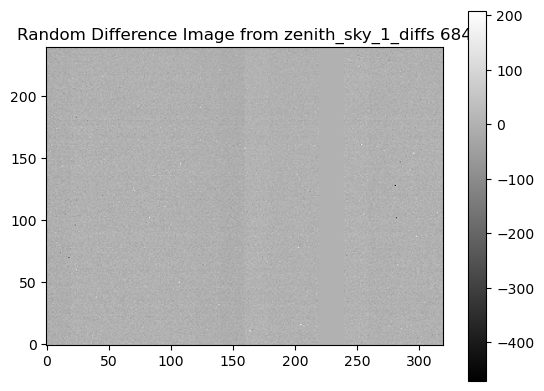

In [13]:
# Pick a random difference image and display it
i = np.random.randint(0, zenith_sky_1_diffs.shape[0])
plt.imshow(zenith_sky_1_diffs[i], cmap='gray', origin='lower')
plt.title("Random Difference Image from zenith_sky_1_diffs {}".format(i))
plt.colorbar()

So this is giving nopw the difference between frames A and B. Now if I draw an aperture in each frame,  

In [14]:
def extract_sky_timeseries(exposures, region, trim=None, annulus=None, statistic="sum"):
    """
    Build a 1D time series x[t] = sky level estimator from a fixed aperture (and optional annulus).

    Parameters
    ----------
    exposures : (n, H, W) ndarray
    region : (y, x, r)
        aperture center and radius in pixels
    trim : (i0, i1) or None
        slice frames: exposures[i0:i1]
    annulus : (r_in, r_out) or None
        if provided, compute annulus background and subtract it from aperture mean/sum
    statistic : {'mean','median','sum'}
        how to summarize pixels inside the aperture

    Returns
    -------
    out : dict with keys:
        'x_ap' : aperture statistic time series (background-subtracted if annulus given)
        'x_ann' : annulus statistic time series (if annulus given)
        'n_pix_ap', 'n_pix_ann'
    """
    if trim is not None:
        exposures = exposures[trim[0]:trim[1]]

    y, x, r = region
    pos = (x, y)

    ap = CircularAperture(pos, r=r)#
    ap_mask = ap.to_mask(method="center")
    # Fix: to_mask() returns a single mask, not a list - remove [0]
    ap_mask = ap_mask.to_image(exposures.shape[1:]).astype(bool)
    n_pix_ap = ap_mask.sum()

    if annulus is not None:
        r_in, r_out = annulus
        an = CircularAnnulus(pos, r_in=r_in, r_out=r_out)
        an_mask = an.to_mask(method="center")
        # Fix: same here - remove [0]
        an_mask = an_mask.to_image(exposures.shape[1:]).astype(bool)
        n_pix_ann = an_mask.sum()
    else:
        an_mask = None
        n_pix_ann = 0

    x_ap = np.empty(exposures.shape[0], dtype=float)
    x_ann = np.empty(exposures.shape[0], dtype=float) if an_mask is not None else None

    for i, frame in enumerate(exposures):
        ap_vals = frame[ap_mask]

        if statistic == "mean":
            ap_stat = np.mean(ap_vals)
        elif statistic == "median":
            ap_stat = np.median(ap_vals)
        elif statistic == "sum":
            ap_stat = np.sum(ap_vals)
        else:
            raise ValueError("statistic must be 'mean', 'median', or 'sum'")

        if an_mask is not None:
            ann_vals = frame[an_mask]
            # robust background: median is usually best
            ann_stat = np.median(ann_vals)
            x_ann[i] = ann_stat

            # subtract background in consistent units:
            # if 'sum', subtract (background * n_pix_ap); if mean/median, subtract background directly
            if statistic == "sum":
                ap_stat = ap_stat - ann_stat * n_pix_ap
            else:
                ap_stat = ap_stat - ann_stat

        x_ap[i] = ap_stat

    out = {"x_ap": x_ap, "n_pix_ap": n_pix_ap}
    if x_ann is not None:
        out.update({"x_ann": x_ann, "n_pix_ann": n_pix_ann})
    return out

In [15]:
# Trimming was already done in chop_demodulate_pairwise, so we can pass the full diffs cube here
zenith_sky_timeseries = extract_sky_timeseries(zenith_sky_1_diffs, region, trim=None)

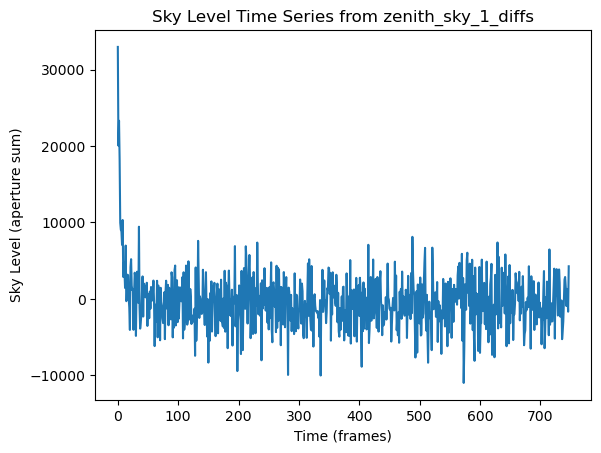

In [16]:
plt.plot(zenith_sky_timeseries['x_ap'][2:])  # Plot only the first 100 points for better visibility
plt.xlabel("Time (frames)")
plt.ylabel("Sky Level (aperture sum)")
plt.title("Sky Level Time Series from zenith_sky_1_diffs")
plt.show()  

Now this is the apeture count for each difference, this should - int theory be 0 mean and have some variance $\sigma^2_{n=1}$. Let's see what it is and associate it with the corresponding freq. 

In [17]:
# find the variance in the sky level time series
sky_variance = np.var(zenith_sky_timeseries['x_ap'])
print("Variance of sky level time series:", sky_variance)
print("at", freqs)

Variance of sky level time series: 2482097193.9190917
at (0.0103, 97.08737864077669, 48.543689320388346)


In [18]:
coadds = np.arange(5, 251)

In [19]:
coadds = np.arange(5, 251)

variances = np.zeros(len(coadds))
f_chop_hz = np.zeros(len(coadds))
f_state_hz = np.zeros(len(coadds))

for index, coadd in enumerate(coadds):
    _, f_state, f_chop = dwell_and_chop_frequencies(frame_dt_s, n=coadd)
    f_chop_hz[index] = f_chop
    f_state_hz[index] = f_state

    dwells = coadd_to_dwells(zenith_sky_1_data, n=coadd, method="sum", trim=TRIM_FRAMES)
    diffs = chop_demodulate_pairwise(dwells)
    timeseries = extract_sky_timeseries(diffs, region, statistic="sum")
    
    variances[index] = np.var(timeseries['x_ap'])

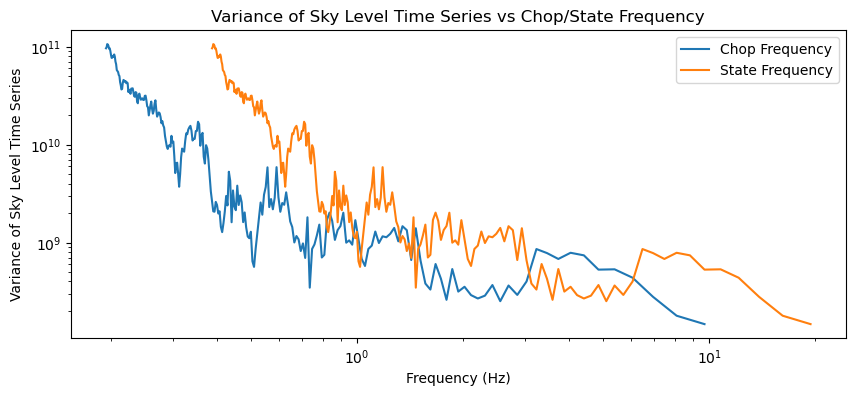

In [20]:
# Plot the results 
plt.figure(figsize=(10,4))
plt.plot(f_chop_hz, variances)
plt.plot(f_state_hz, variances)
plt.xscale('log')
plt.yscale('log')
plt.title("Variance of Sky Level Time Series vs Chop/State Frequency")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Variance of Sky Level Time Series")
plt.legend(["Chop Frequency", "State Frequency"])
plt.show()

John suggested to try and divide the frames by the n+1th frame to better isolate the sky signal - basically only evaluating fractional sky changes.

So, this works only assuming that you have no additative systematics.

/tmp/ipykernel_79221/4095756987.py:2: RuntimeWarning: invalid value encountered in divide
  normalized_frames = zenith_sky_1_data[1:] / zenith_sky_1_data[:-1]


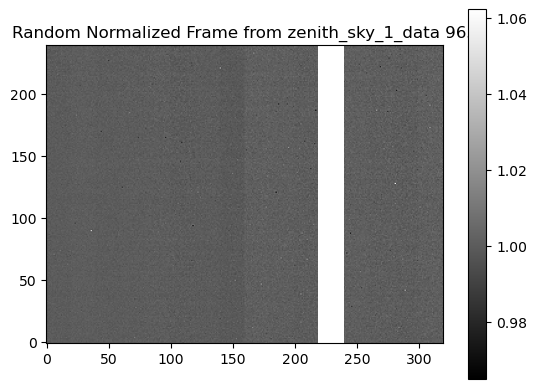

In [63]:
# divide each frame in the raw stack by the one before it 
normalized_frames = zenith_sky_1_data[1:] / zenith_sky_1_data[:-1]
# Plot a random normalized frame to see what it looks like
i = np.random.randint(0, normalized_frames.shape[0])
plt.imshow(normalized_frames[i], cmap='gray', origin='lower')
plt.title("Random Normalized Frame from zenith_sky_1_data {}".format(i))
plt.colorbar()
plt.show()

So, each frame is on the order unity, which I expect. So this is the fractional change from the previous image. Since the sky and telescope aren't changing, this represents the change in sky at this pixel - It's now important to preserve the pixel information. 

In [64]:
# Now treat the normalized frames as if they were the difference images and extract the sky timeseries from them
variances_div = np.zeros(len(coadds))
f_chop_hz_div = np.zeros(len(coadds))
f_state_hz_div = np.zeros(len(coadds))

for index, coadd in enumerate(coadds):
    _, f_state, f_chop = dwell_and_chop_frequencies(frame_dt_s, n=coadd)
    f_chop_hz_div[index] = f_chop
    f_state_hz_div[index] = f_state

    dwells = coadd_to_dwells(normalized_frames, n=coadd, method="sum", trim=TRIM_FRAMES)
    diffs = chop_demodulate_pairwise(dwells)
    timeseries = extract_sky_timeseries(diffs, region, statistic="sum")
    
    variances[index] = np.var(timeseries['x_ap'])

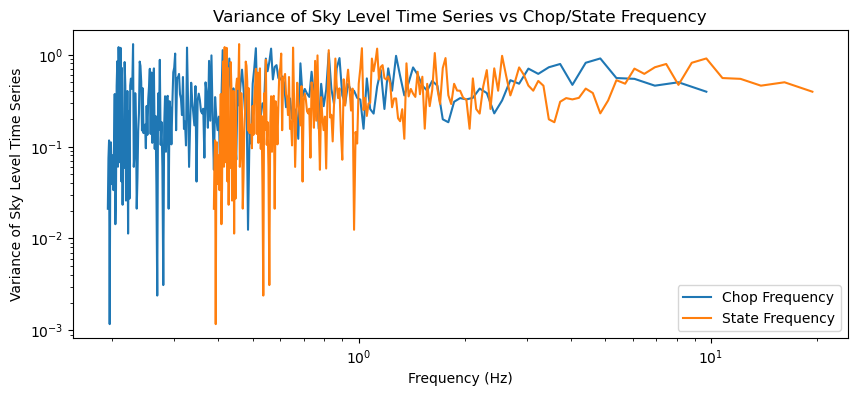

In [65]:
# Plot the results 
plt.figure(figsize=(10,4))
plt.plot(f_chop_hz, variances)
plt.plot(f_state_hz, variances)
plt.xscale('log')
plt.yscale('log')
plt.title("Variance of Sky Level Time Series vs Chop/State Frequency")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Variance of Sky Level Time Series")
plt.legend(["Chop Frequency", "State Frequency"])
plt.show()

since this seems to be working - inject a point source in the A frames 

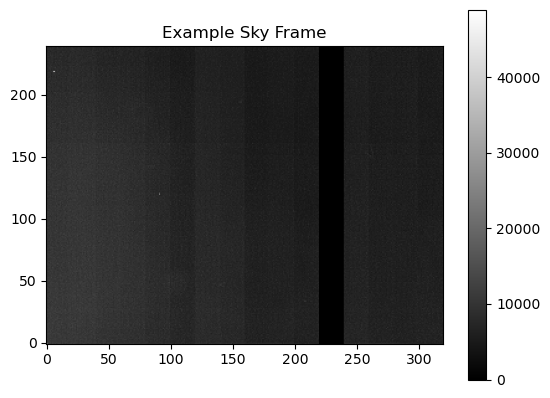

In [56]:
# inject point source in the A frames
# Grab a sky frame 
sky_frame = zenith_sky_1_data[133]  # Just take the first frame as an example
plt.imshow(sky_frame, cmap='gray', origin='lower')
plt.title("Example Sky Frame")
plt.colorbar()
plt.show()

In [ ]:
# inject a point source at the center of the aperture in the A frames and see how it appears in the difference images
y, x, r = region
aperture = CircularAperture((x, y), r=r)
aperture_mask = aperture.to_mask(method="center").to_image(sky_frame.shape).astype(bool)
# Create a copy of the sky frame to inject the source
injected_frame = sky_frame.copy()
# Inject a point source (e.g., add a value of 1000 to the pixels

An Equivalent point source may be 3200 Phaethon - using the NEO thermal model at 10 microns, this object has a flux of about 9x10^-14 W m^-2 micron^-1. 

The size of this object is about 5.8 km. and data was taken on 1984 December 20 with UKIRT. 
Using JPL Horizons: 
This object had a geocentric distance of 0.245 AU.

In [59]:
au_to_m = 149597870700  # Astronomical Unit in meters

In [61]:
# The angular size of 3200 Phaeton would be 
angular_size_phaethon = 5.8e3 / (0.245 * au_to_m) * 206265  # in arcseconds
print("Angular size of 3200 Phaeton at 0.245 AU:", angular_size_phaethon, "arcseconds")

Angular size of 3200 Phaeton at 0.245 AU: 0.03264089348609496 arcseconds


In [62]:
# compute the diffraction limit of irtf 
wavelength_m = 10e-6  # 10 microns in meters
telescope_diameter_m = 3.0  # IRTF diameter in meters
diffraction_limit_rad = 1.22 * wavelength_m / telescope_diameter_m  # in radians
diffraction_limit_arcsec = diffraction_limit_rad * (180/np.pi) * 3600  # convert to arcseconds
print("Diffraction limit of IRTF at 10 microns:", diffraction_limit_arcsec, "arcseconds")

Diffraction limit of IRTF at 10 microns: 0.8388102120715253 arcseconds


In [22]:
def coadd_to_dwells(raw_cube, n, method="sum", trim=None):
    """
    Convert fast-read raw frames into 'dwell' frames by binning n consecutive frames.

    Parameters
    ----------
    raw_cube : (N, ny, nx) ndarray
        Fast-read frames.
    n : int
        Number of fast frames per dwell (software-emulated dwell / coadd).
    method : {"mean","sum"}
        How to combine frames inside each dwell.
    trim : (i0, i1) or None
        Optional slice on the raw frames before binning.

    Returns
    -------
    dwell_cube : (N_dwell, ny, nx) ndarray
        Coadded dwell frames.
    """
    if trim is not None:
        raw_cube = raw_cube[trim[0]:trim[1]]

    raw_cube = np.asarray(raw_cube)
    if raw_cube.ndim != 3:
        raise ValueError("raw_cube must have shape (N, ny, nx)")

    if n < 1:
        raise ValueError("n must be >= 1")

    N, ny, nx = raw_cube.shape
    Ntrim = (N // n) * n
    if Ntrim < n:
        raise ValueError("Not enough frames to form one dwell.")

    blocks = raw_cube[:Ntrim].reshape(-1, n, ny, nx)

    if method == "mean":
        dwell_cube = blocks.mean(axis=1)
    elif method == "sum":
        dwell_cube = blocks.sum(axis=1)
    else:
        raise ValueError("method must be 'mean' or 'sum'")

    return dwell_cube


def make_chop_states(n_dwells):
    """
    ABAB... chop states at the dwell level (A=even, B=odd).
    """
    return np.where((np.arange(n_dwells) % 2) == 0, "A", "B")


def chop_demodulate_pairwise(dwell_cube):
    """
    Pairwise demodulation for ABAB... sequence:
        diff[m] = A[m] - B[m]  with A=even dwells, B=odd dwells

    Parameters
    ----------
    dwell_cube : (N_dwell, ny, nx) ndarray

    Returns
    -------
    diff_cube : (N_pairs, ny, nx) ndarray
        One chopped difference image per AB pair.
    """
    dwell_cube = np.asarray(dwell_cube)
    if dwell_cube.ndim != 3:
        raise ValueError("dwell_cube must have shape (N_dwell, ny, nx)")

    N, ny, nx = dwell_cube.shape
    n_pairs = N // 2
    if n_pairs < 1:
        raise ValueError("Need at least 2 dwells (A and B) to form one pair.")

    d2 = dwell_cube[:2 * n_pairs]
    A = d2[0::2]
    B = d2[1::2]
    return A - B


def stack_cube(cube, method="mean"):
    """
    Stack a cube along time axis into a single image.
    """
    cube = np.asarray(cube)
    if cube.ndim != 3:
        raise ValueError("cube must have shape (N, ny, nx)")

    if method == "mean":
        return cube.mean(axis=0)
    elif method == "sum":
        return cube.sum(axis=0)
    else:
        raise ValueError("method must be 'mean' or 'sum'")


# --- Optional: a tiny helper to report frequencies cleanly ---
def dwell_and_chop_frequencies(frame_dt_s, n):
    """
    frame_dt_s: cadence of fast-read frames
    n: frames per dwell

    Returns:
      t_dwell, f_state, f_chop
    where:
      f_state = 1/t_dwell  (A->B state switching rate)
      f_chop  = 1/(2*t_dwell) (full AB cycle rate)
    """
    t_dwell = frame_dt_s * n
    f_state = 1.0 / t_dwell
    f_chop = 1.0 / (2.0 * t_dwell)
    return t_dwell, f_state, f_chop

In [23]:
import numpy as np
from photutils.aperture import CircularAperture, CircularAnnulus

def extract_sky_timeseries(exposures, region, trim=None, annulus=None, statistic="mean"):
    """
    Build a 1D time series x[t] = sky level estimator from a fixed aperture (and optional annulus).

    Parameters
    ----------
    exposures : (n, H, W) ndarray
    region : (y, x, r)
        aperture center and radius in pixels
    trim : (i0, i1) or None
        slice frames: exposures[i0:i1]
    annulus : (r_in, r_out) or None
        if provided, compute annulus background and subtract it from aperture mean/sum
    statistic : {'mean','median','sum'}
        how to summarize pixels inside the aperture

    Returns
    -------
    out : dict with keys:
        'x_ap' : aperture statistic time series (background-subtracted if annulus given)
        'x_ann' : annulus statistic time series (if annulus given)
        'n_pix_ap', 'n_pix_ann'
    """
    if trim is not None:
        exposures = exposures[trim[0]:trim[1]]

    y, x, r = region
    pos = (x, y)

    ap = CircularAperture(pos, r=r)#
    ap_mask = ap.to_mask(method="center")
    # Fix: to_mask() returns a single mask, not a list - remove [0]
    ap_mask = ap_mask.to_image(exposures.shape[1:]).astype(bool)
    n_pix_ap = ap_mask.sum()

    if annulus is not None:
        r_in, r_out = annulus
        an = CircularAnnulus(pos, r_in=r_in, r_out=r_out)
        an_mask = an.to_mask(method="center")
        # Fix: same here - remove [0]
        an_mask = an_mask.to_image(exposures.shape[1:]).astype(bool)
        n_pix_ann = an_mask.sum()
    else:
        an_mask = None
        n_pix_ann = 0

    x_ap = np.empty(exposures.shape[0], dtype=float)
    x_ann = np.empty(exposures.shape[0], dtype=float) if an_mask is not None else None

    for i, frame in enumerate(exposures):
        ap_vals = frame[ap_mask]

        if statistic == "mean":
            ap_stat = np.mean(ap_vals)
        elif statistic == "median":
            ap_stat = np.median(ap_vals)
        elif statistic == "sum":
            ap_stat = np.sum(ap_vals)
        else:
            raise ValueError("statistic must be 'mean', 'median', or 'sum'")

        if an_mask is not None:
            ann_vals = frame[an_mask]
            # robust background: median is usually best
            ann_stat = np.median(ann_vals)
            x_ann[i] = ann_stat

            # subtract background in consistent units:
            # if 'sum', subtract (background * n_pix_ap); if mean/median, subtract background directly
            if statistic == "sum":
                ap_stat = ap_stat - ann_stat * n_pix_ap
            else:
                ap_stat = ap_stat - ann_stat

        x_ap[i] = ap_stat

    out = {"x_ap": x_ap, "n_pix_ap": n_pix_ap}
    if x_ann is not None:
        out.update({"x_ann": x_ann, "n_pix_ann": n_pix_ann})
    return out


In [24]:
def variance_vs_frequency_series(x, coadds_list, frame_dt_s, method, ddof=1):
    """
    For each coadds, average x into blocks and compute Var(block_means).
    """
    out = {"coadds": [], "f_eff_hz": [], "n_blocks": [], "var": []}

    for n in coadds_list:
        Ntrim = (len(x) // n) * n
        if Ntrim < 2*n:
            continue
        if method == "mean":
            xb = x[:Ntrim].reshape(-1, n).mean(axis=1)   # mean keeps units consistent
        if method  == "sum":
            xb = x[:Ntrim].reshape(-1, n).sum(axis=1)   # more physical for total flux
        out["coadds"].append(n)
        out["f_eff_hz"].append(1.0 / (frame_dt_s * n))
        out["n_blocks"].append(len(xb))
        out["var"].append(np.var(xb, ddof=ddof))

    return {k: np.array(v) for k, v in out.items()}


In [25]:
def variance_vs_frequency_chop_proxy(x, coadds_list, frame_dt_s, method, ddof=1):
    """
    For each coadds, compute block means then take successive differences and compute Var(diffs).

    
    """
    # Initialize output dictionary
    out = {"coadds": [], "f_eff_hz": [], "n_blocks": [], "var_diff": []}

    # Loop over each coadds value
    for n in coadds_list:
        # Trim x to a multiple of n
        Ntrim = (len(x) // n) * n
        if Ntrim < 3*n:   # need at least 3 blocks to get >=2 diffs
            continue
        # Groups n consecutive frames and computes their mean
        if method == "mean":
            xb = x[:Ntrim].reshape(-1, n).mean(axis=1)   # mean keeps units consistent
        if method  == "sum":
            xb = x[:Ntrim].reshape(-1, n).sum(axis=1)   # more physical for total flux

        # Computes successive differences (i.e. A - B subtraction)
        d = np.diff(xb)

        out["coadds"].append(n)
        out["f_eff_hz"].append(1.0 / (frame_dt_s * n))
        out["n_blocks"].append(len(xb))
        out["var_diff"].append(np.var(d, ddof=ddof))

    return {k: np.array(v) for k, v in out.items()}


In [26]:
import numpy as np

def variance_vs_frequency_chop_proxy_true(x, coadds_list, frame_dt_s, method="mean", ddof=1):
    out = {"coadds": [], "f_eff_hz": [], "n_blocks": [], "n_pairs": [], "var_diff": []}

    for n in coadds_list:
        Ntrim = (len(x) // n) * n
        if Ntrim < 4*n:   # need at least 2 A-B pairs
            continue

        if method == "mean":
            xb = x[:Ntrim].reshape(-1, n).mean(axis=1)
        elif method == "sum":
            xb = x[:Ntrim].reshape(-1, n).sum(axis=1)
        else:
            raise ValueError("method must be 'mean' or 'sum'")

        n_pairs = len(xb) // 2
        xb2 = xb[:2*n_pairs]
        d = xb2[0::2] - xb2[1::2]   # A - B

        out["coadds"].append(n)
        out["f_eff_hz"].append(1.0 / (frame_dt_s * n))
        out["n_blocks"].append(len(xb))
        out["n_pairs"].append(n_pairs)
        out["var_diff"].append(np.var(d, ddof=ddof))

    return {k: np.array(v) for k, v in out.items()}


In [27]:
zenith_dark = extract_sky_timeseries(zenith_dark_data, region, trim=None, annulus=None, statistic="mean")

zenith_sky_1 = extract_sky_timeseries(zenith_sky_1_data, region, trim=None, annulus=None, statistic="mean")

zenith_sky_2 = extract_sky_timeseries(zenith_sky_2_data, region, trim=None, annulus=None, statistic="mean")

zenith_sky_3 = extract_sky_timeseries(zenith_sky_3_data, region, trim=None, annulus=None, statistic="mean")


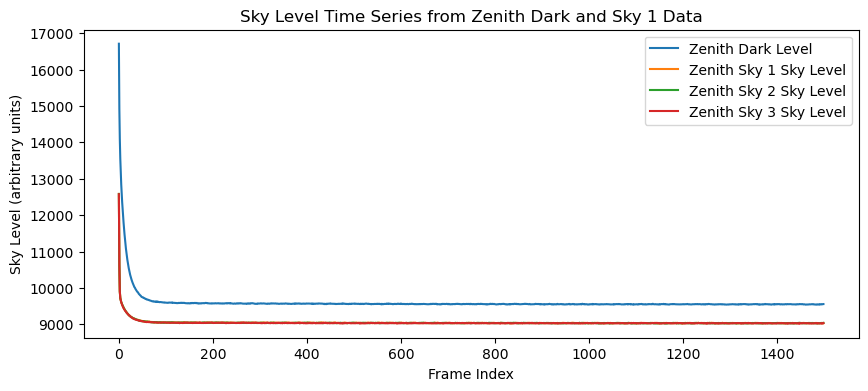

In [28]:
# First plot the non-trimmed time series
plt.figure(figsize=(10,4))
plt.plot(zenith_dark['x_ap'], label='Zenith Dark Level')
plt.plot(zenith_sky_1['x_ap'], label='Zenith Sky 1 Sky Level')
plt.plot(zenith_sky_2['x_ap'], label='Zenith Sky 2 Sky Level')
plt.plot(zenith_sky_3['x_ap'], label='Zenith Sky 3 Sky Level')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith Dark and Sky 1 Data')
plt.legend()
plt.show()

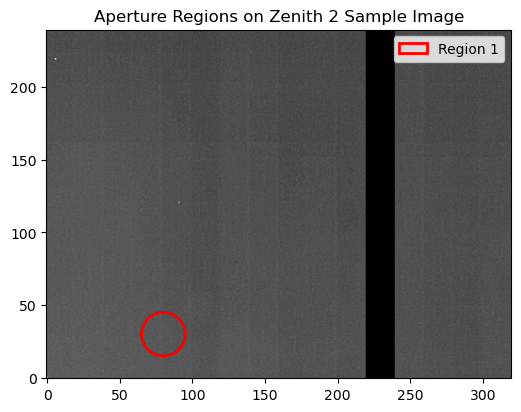

In [29]:
# Plot the two aperture regions on the image 
plt.figure(figsize=(6,6))
plt.imshow(zenith_dark_data[0], cmap='gray', origin='lower')
ap1 = CircularAperture((region[1], region[0]), r=region[2])
# ap2 = CircularAperture((region_2[1], region_2[0]), r=region_2[2])
ap1.plot(color='red', lw=2, label='Region 1')
#ap2.plot(color='blue', lw=2, label='Region 2')
plt.title('Aperture Regions on Zenith 2 Sample Image')
plt.legend()
plt.show()

the increase in counts as exposures increase is okay, you actually expect this if this is true dark current (detector warming up)

In [30]:
zenith_dark = extract_sky_timeseries(zenith_dark_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")

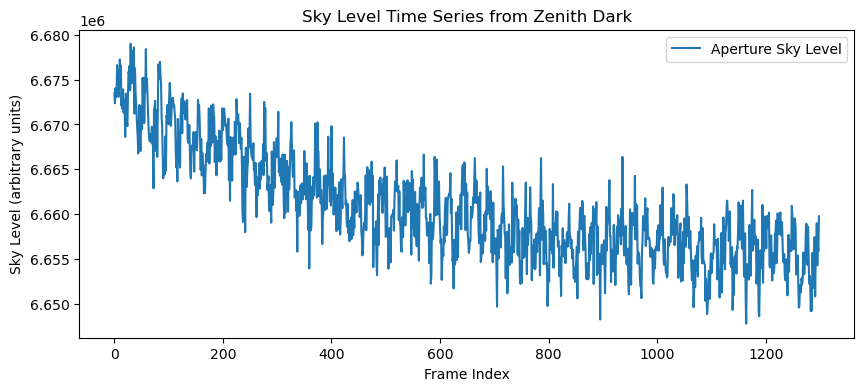

In [31]:
plt.figure(figsize=(10,4))
plt.plot(zenith_dark['x_ap'], label='Aperture Sky Level')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith Dark')
plt.legend()
plt.show()

In [32]:
frame_dt_s = 0.0103  # 10 ms cadence

Text(0, 0.5, 'Power Spectral Density')

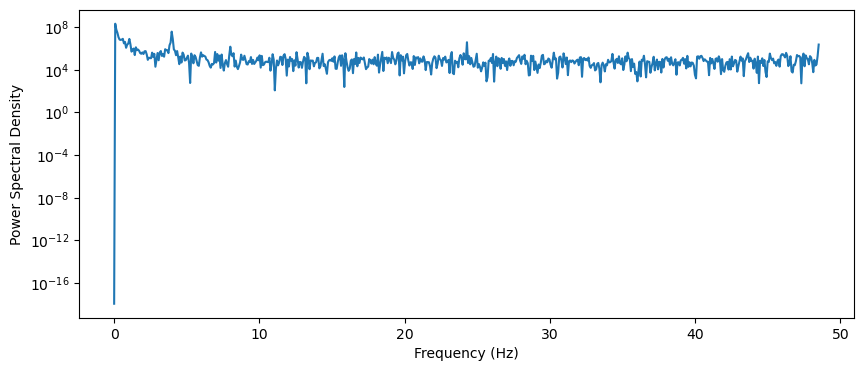

In [33]:
# try simple fourier analysis of the time series to see if we can detect the chop frequency
from scipy.signal import periodogram
fs = 1.0 / frame_dt_s  # sampling frequency in Hz
f, Pxx = periodogram(zenith_dark['x_ap'], fs=fs)
plt.figure(figsize=(10,4))
plt.semilogy(f, Pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')

In [34]:
# clearly there's a peak in the signal at around 4 hz for values greater than 1 hz. find the exact frequency of the peak and compare to the expected chop frequency from the metadata
# limit to frequencies above 1 hz to avoid low-frequency noise
f_lim = f[f > 1]
Pxx_lim = Pxx[f > 1]
peak_idx = np.argmax(Pxx_lim)
peak_freq = f_lim[peak_idx]
print(f"Peak frequency in periodogram: {peak_freq:.3f} Hz")


Peak frequency in periodogram: 3.961 Hz


In [35]:
zenith_sky_1 = extract_sky_timeseries(zenith_sky_1_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")

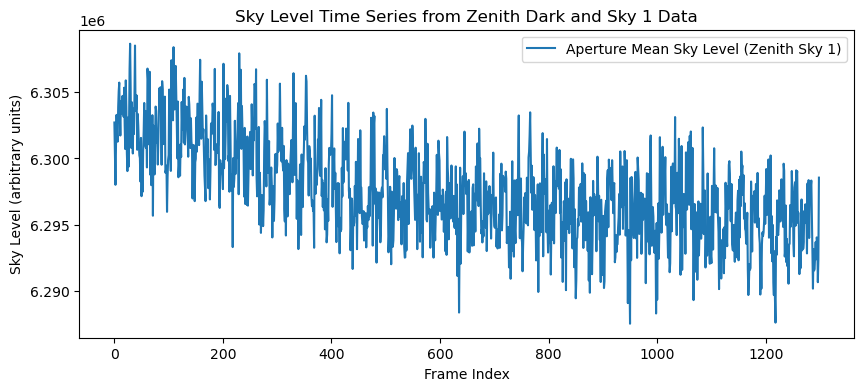

In [36]:
plt.figure(figsize=(10,4))
plt.plot(zenith_sky_1['x_ap'], label='Aperture Mean Sky Level (Zenith Sky 1)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith Dark and Sky 1 Data')
plt.legend()
plt.show()

In [37]:
zenith_sky_2 = extract_sky_timeseries(zenith_sky_2_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")

Text(0.5, 1.0, 'Sky Level Time Series Sky 2 Data')

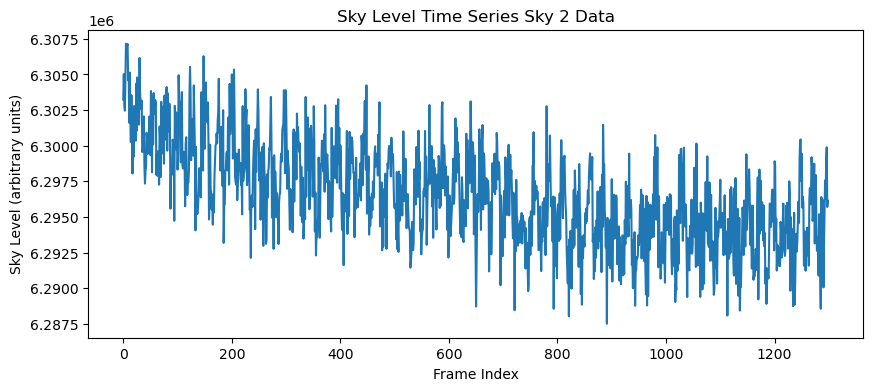

In [38]:
plt.figure(figsize=(10,4))
plt.plot(zenith_sky_2['x_ap'], label='Aperture Mean Sky Level (Zenith Sky 2)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series Sky 2 Data')

In [39]:
zenith_sky_3 = extract_sky_timeseries(zenith_sky_3_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")

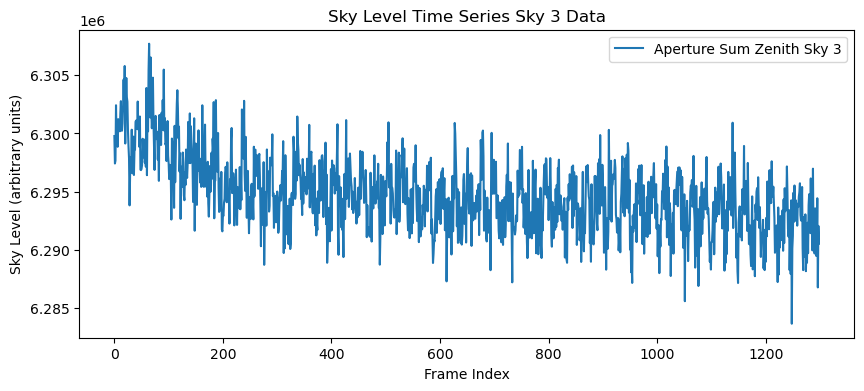

In [40]:
plt.figure(figsize=(10,4))
plt.plot(zenith_sky_3['x_ap'], label='Aperture Sum Zenith Sky 3')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series Sky 3 Data')
plt.legend()
plt.show()

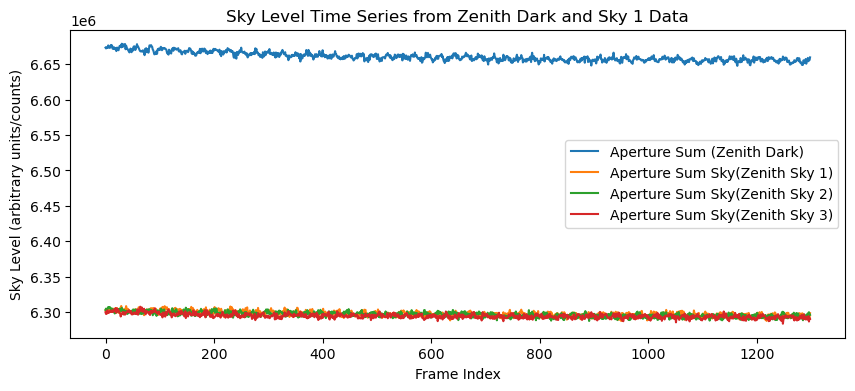

In [41]:
# Overplot the all together 
plt.figure(figsize=(10,4))
plt.plot(zenith_dark['x_ap'], label='Aperture Sum (Zenith Dark)')
plt.plot(zenith_sky_1['x_ap'], label='Aperture Sum Sky(Zenith Sky 1)')
plt.plot(zenith_sky_2['x_ap'], label='Aperture Sum Sky(Zenith Sky 2)')
plt.plot(zenith_sky_3['x_ap'], label='Aperture Sum Sky(Zenith Sky 3)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units/counts)')
plt.title('Sky Level Time Series from Zenith Dark and Sky 1 Data')
plt.legend()
plt.show()

# Simulate Chopping

In [42]:
# Make a list of integers for coadds 5 - 100
coadds_list = np.arange(5, 251)
#cadds_list = [6, 7, 8,9, 10,20,30, 40, 50, 60, 70, 80, 90, 100]

In [43]:
zenith_sky_chopped_1 = variance_vs_frequency_chop_proxy(zenith_sky_1['x_ap'], coadds_list, frame_dt_s=0.0103, method="sum")
zenith_sky_chopped_2 = variance_vs_frequency_chop_proxy(zenith_sky_2['x_ap'], coadds_list, frame_dt_s=0.0103, method="sum")
zenith_sky_chopped_3 = variance_vs_frequency_chop_proxy(zenith_sky_3['x_ap'], coadds_list, frame_dt_s=0.0103, method="sum")

zenith_sky_dark = variance_vs_frequency_chop_proxy(zenith_dark['x_ap'], coadds_list, frame_dt_s=0.0103, method="sum")

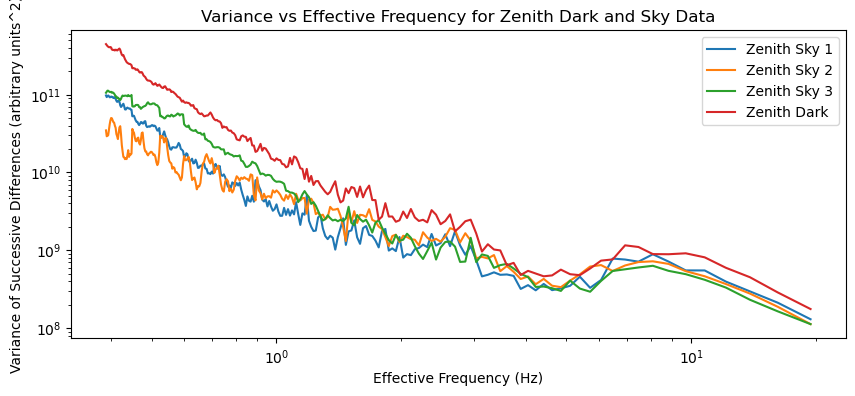

In [44]:
plt.figure(figsize=(10,4))
plt.plot(zenith_sky_chopped_1['f_eff_hz'], zenith_sky_chopped_1['var_diff'], label='Zenith Sky 1')
plt.plot(zenith_sky_chopped_2['f_eff_hz'], zenith_sky_chopped_2['var_diff'], label='Zenith Sky 2')
plt.plot(zenith_sky_chopped_3['f_eff_hz'], zenith_sky_chopped_3['var_diff'], label='Zenith Sky 3')
plt.plot(zenith_sky_dark['f_eff_hz'], zenith_sky_dark['var_diff'], label='Zenith Dark')
plt.xlabel('Effective Frequency (Hz)')
plt.ylabel('Variance of Successive Differences (arbitrary units^2)')
plt.title('Variance vs Effective Frequency for Zenith Dark and Sky Data')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.show()

Clearly, the detector has some gain issues, so we can actually look at D/N instead replot in terms of DN per pixel per second

Use the other version of the function  

In [45]:
zenith_sky_1_true = variance_vs_frequency_chop_proxy_true(zenith_sky_1['x_ap'], coadds_list, frame_dt_s=0.0103, method="sum")
zenith_sky_2_true = variance_vs_frequency_chop_proxy_true(zenith_sky_2['x_ap'], coadds_list, frame_dt_s=0.0103, method="sum")
zenith_sky_3_true = variance_vs_frequency_chop_proxy_true(zenith_sky_3['x_ap'], coadds_list, frame_dt_s=0.0103, method="sum")   
zenith_sky_dark_true = variance_vs_frequency_chop_proxy_true(zenith_dark['x_ap'], coadds_list, frame_dt_s=0.0103, method="sum")

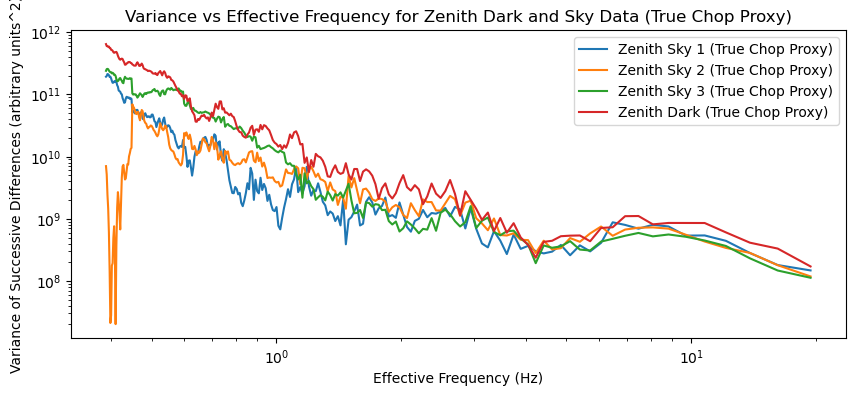

In [46]:
# Plot the results 
plt.figure(figsize=(10,4))
plt.plot(zenith_sky_1_true['f_eff_hz'], zenith_sky_1_true['var_diff'], label='Zenith Sky 1 (True Chop Proxy)')
plt.plot(zenith_sky_2_true['f_eff_hz'], zenith_sky_2_true['var_diff'], label='Zenith Sky 2 (True Chop Proxy)')
plt.plot(zenith_sky_3_true['f_eff_hz'], zenith_sky_3_true['var_diff'], label='Zenith Sky 3 (True Chop Proxy)')  
plt.plot(zenith_sky_dark_true['f_eff_hz'], zenith_sky_dark_true['var_diff'], label='Zenith Dark (True Chop Proxy)')
plt.xlabel('Effective Frequency (Hz)')
plt.ylabel('Variance of Successive Differences (arbitrary units^2)')
plt.title('Variance vs Effective Frequency for Zenith Dark and Sky Data (True Chop Proxy)')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.show()

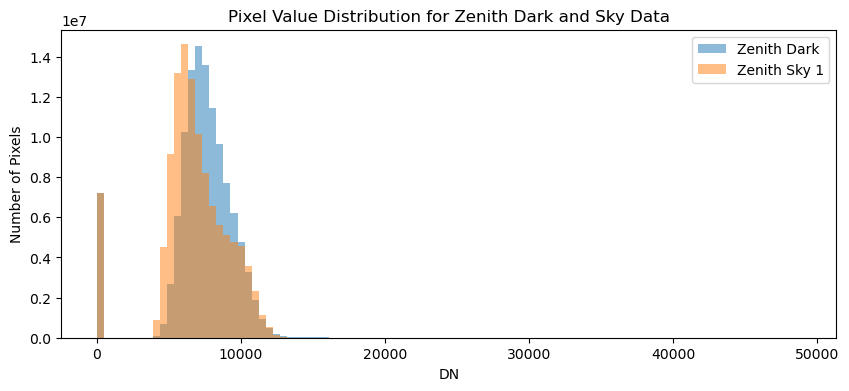

In [47]:
# Take the original image and make a histogram of all pixel values to see the distribution of pixel values in the image
plt.figure(figsize=(10,4))
plt.hist(zenith_dark_data.flatten(), bins=100, alpha=0.5, label='Zenith Dark')
plt.hist(zenith_sky_1_data.flatten(), bins=100, alpha=0.5, label='Zenith Sky 1')
# plt.hist(zenith_sky_2_data.flatten(), bins=100, alpha=0.5, label='Zenith Sky 2')
# plt.hist(zenith_sky_3_data.flatten(), bins=100, alpha=0.5, label='Zenith Sky 3')
plt.xlabel('DN')
plt.ylabel('Number of Pixels')
plt.title('Pixel Value Distribution for Zenith Dark and Sky Data')
plt.legend()
plt.show()

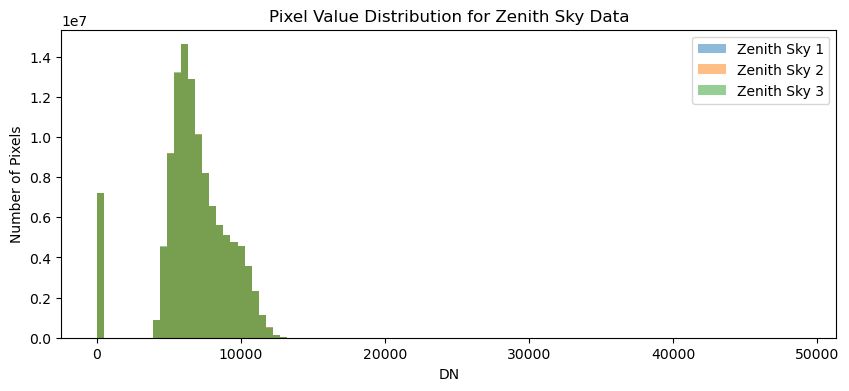

In [48]:
# Plot all the sky data frames
plt.figure(figsize=(10,4))
plt.hist(zenith_sky_1_data.flatten(), bins=100, alpha=0.5, label='Zenith Sky 1')
plt.hist(zenith_sky_2_data.flatten(), bins=100, alpha=0.5, label='Zenith Sky 2')
plt.hist(zenith_sky_3_data.flatten(), bins=100, alpha=0.5, label='Zenith Sky 3')
plt.xlabel('DN')
plt.ylabel('Number of Pixels')
plt.title('Pixel Value Distribution for Zenith Sky Data')   
plt.legend()
plt.show()

The itime for the array is 0.0103 seconds. So we want to find the DN/per pixel per second 

Median of Zenith Dark in counts/s: 721359.2233009709
Median of Zenith Sky 1 in counts/s: 645631.067961165


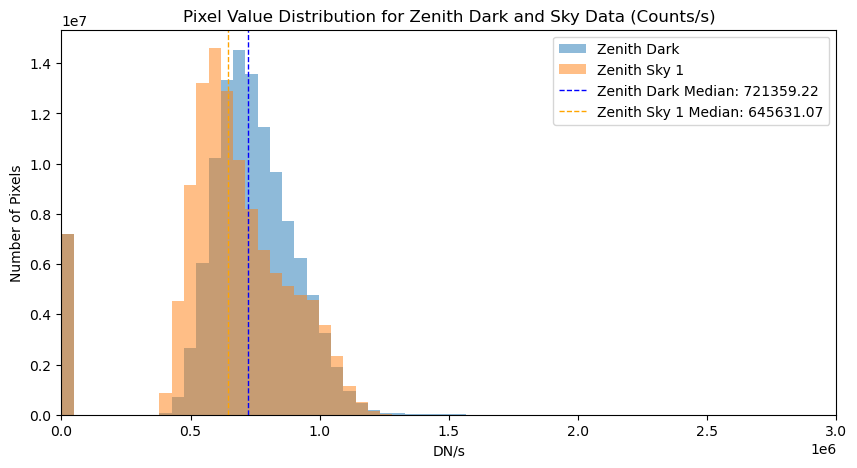

In [49]:
# Take all the values of the dark and the zenith sky one and scale by 1/0.0103 to convert to counts/s and then make a histogram of the pixel values to see the distribution of pixel values in the image in counts/s
plt.figure(figsize=(10,5))
plt.hist(zenith_dark_data.flatten() / 0.0103, bins=100, alpha=0.5, label='Zenith Dark')
plt.hist(zenith_sky_1_data.flatten() / 0.0103, bins=100, alpha=0.5, label='Zenith Sky 1')
plt.xlabel('DN/s')
plt.ylabel('Number of Pixels')
plt.title('Pixel Value Distribution for Zenith Dark and Sky Data (Counts/s)')
plt.legend()

# print the median of the dark and the zenith sky one in counts/s
print(f'Median of Zenith Dark in counts/s: {np.median(zenith_dark_data.flatten() / 0.0103)}')
print(f'Median of Zenith Sky 1 in counts/s: {np.median(zenith_sky_1_data.flatten() / 0.0103)}')

axvline_dark = np.median(zenith_dark_data.flatten() / 0.0103)
axvline_sky_1 = np.median(zenith_sky_1_data.flatten() / 0.0103)
plt.axvline(axvline_dark, color='blue', linestyle='dashed', linewidth=1, label=f'Zenith Dark Median: {axvline_dark:.2f}')
plt.axvline(axvline_sky_1, color='orange', linestyle='dashed', linewidth=1, label=f'Zenith Sky 1 Median: {axvline_sky_1:.2f}')
plt.xlim(0, 3e6)
plt.legend()    
plt.show()

Compare this to the expected counts you might expect to see given the sky T_sky = 250 K and the telescope at T_tel = 273 K

We use a modified version of the compute sky background rate code 

In [50]:
from sky_sim import compute_sky_background_rate_with_tel

background_rate, sky_rate, telescope_rate = compute_sky_background_rate_with_tel(
    wavelength=10e-6, 
    temperature_sky=250,      # 10 μm
    temperature_telescope=273, # mirror
    emissivity_telescope=0.1   # Aluminum mirror
)

Sky background rate: 1.74e+08 photons/s/pixel
Telescope thermal emission rate: 2.83e+08 photons/s/pixel
Total background rate: 4.56e+08 photons/s/pixel
Telescope contribution: 61.9%


Median of Zenith Dark in counts/s: 721359.2233009709
Median of Zenith Sky 1 in counts/s: 645631.067961165


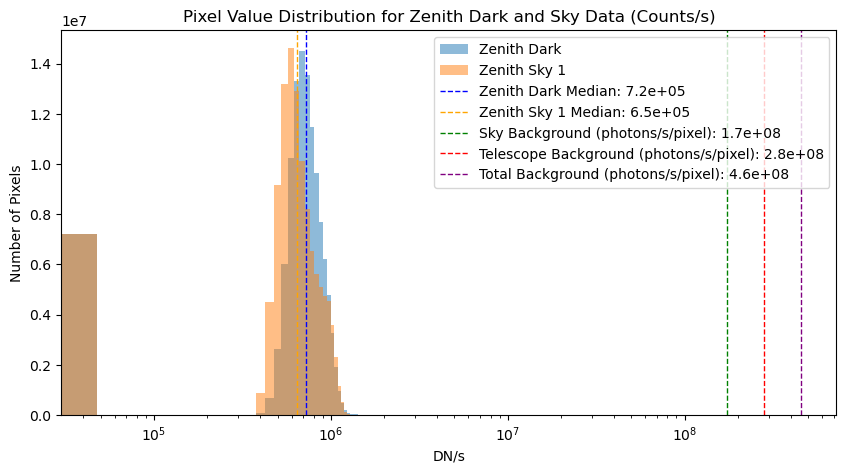

In [51]:
# Add the expected sky and telescope background rates in counts/s/pixel to the plot as vertical lines
plt.figure(figsize=(10,5))
plt.hist(zenith_dark_data.flatten() / 0.0103, bins=100, alpha=0.5, label='Zenith Dark')
plt.hist(zenith_sky_1_data.flatten() / 0.0103, bins=100, alpha=0.5, label='Zenith Sky 1')
plt.xlabel('DN/s')
plt.ylabel('Number of Pixels')
plt.title('Pixel Value Distribution for Zenith Dark and Sky Data (Counts/s)')

# print the median of the dark and the zenith sky one in counts/s
print(f'Median of Zenith Dark in counts/s: {np.median(zenith_dark_data.flatten() / 0.0103)}')
print(f'Median of Zenith Sky 1 in counts/s: {np.median(zenith_sky_1_data.flatten() / 0.0103)}')

axvline_dark = np.median(zenith_dark_data.flatten() / 0.0103)
axvline_sky_1 = np.median(zenith_sky_1_data.flatten() / 0.0103)
plt.axvline(axvline_dark, color='blue', linestyle='dashed', linewidth=1, label=f'Zenith Dark Median: {axvline_dark:.1e}')
plt.axvline(axvline_sky_1, color='orange', linestyle='dashed', linewidth=1, label=f'Zenith Sky 1 Median: {axvline_sky_1:.1e}')
axvline_sky = sky_rate
axvline_tel = telescope_rate
plt.axvline(axvline_sky, color='green', linestyle='dashed', linewidth=1, label=f'Sky Background (photons/s/pixel): {axvline_sky:.1e}')
plt.axvline(axvline_tel, color='red', linestyle='dashed', linewidth=1, label=f'Telescope Background (photons/s/pixel): {axvline_tel:.1e}')
plt.axvline(background_rate, color='purple', linestyle='dashed', linewidth=1, label=f'Total Background (photons/s/pixel): {background_rate:.1e}')
plt.legend()
plt.xscale('log')
plt.show()

In [52]:
from scipy.ndimage import uniform_filter1d

First just try plotting the values and looking at the scatter we'll just bin the data and see


In [53]:
#  

In [54]:
# binned twice 
coadds_2 = uniform_filter1d(z2['x_ap'], size=2, mode='nearest')[::2]
coadds_3 = uniform_filter1d(z2['x_ap'], size=3, mode='nearest')[::3]
coadds_5 = uniform_filter1d(z2['x_ap'], size=5,
    mode='nearest')[::5]
coadds_10 = uniform_filter1d(z2['x_ap'], size=10,
    mode='nearest')[::10]
coadds_20 = uniform_filter1d(z2['x_ap'], size=20,
    mode='nearest')[::20]
coadds_50 = uniform_filter1d(z2['x_ap'], size=50,
    mode='nearest')[::50]   
coadds_100 = uniform_filter1d(z2['x_ap'], size=100,
    mode='nearest')[::100]
caoadds_200 = uniform_filter1d(z2['x_ap'], size=200,
    mode='nearest')[::200]

NameError: name 'z2' is not defined

In [ ]:
#  overplot the binned data
plt.figure(figsize=(20, 6))
plt.plot(z2['x_ap'], label='Aperture Mean Sky Level', alpha = 0.3)
plt.plot(z3['x_ap'], label='Aperture Mean Sky Level (Zenith 3)', alpha = 0.3)
plt.scatter(range(0, len(z2['x_ap']), 2), coadds_2, label='Binned (2 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 3), coadds_3, label='Binned (3 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 5), coadds_5, label='Binned (5 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 10), coadds_10, label='Binned (10 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 20), coadds_20, label='Binned (20 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 50), coadds_50, label='Binned (50 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 100), coadds_100, label='Binned (100 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 200), caoadds_200, label='Binned (200 frames) Sky Level', marker='.')

plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series with Binned Data')
plt.legend()
plt.show()

In [ ]:
# plot and fill in the 1 sigma ranges for each binned series

plt.figure(figsize=(10, 6))
for label, (bmin, bmax) in binned_stats.items():
    plt.fill_betweenx([bmin, bmax], 0, len(z2['x_ap']), alpha=0.2, label=f'{label} range')      
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Range of Sky Levels for Each Binned Series')
plt.legend()
plt.show()

In [ ]:
raw_cube = zenith_sky_1_data
frame_dt_s = 0.0103
n=3

In [ ]:
# Choose an aperture and NO annulus
ts_raw = extract_sky_timeseries(raw_cube, region=region, annulus=None, statistic="sum")
x_raw = ts_raw["x_ap"]

# Old pipeline (your existing function)
out_old = variance_vs_frequency_chop_proxy_true(
    x_raw, coadds_list=[n], frame_dt_s=frame_dt_s, method="sum", ddof=1
)
var_old = out_old["var_diff"][0]

# New pipeline: coadd images -> extract timeseries -> pairwise diff -> var
dwell = coadd_to_dwells(raw_cube, n=n, method="sum")
ts_dwell = extract_sky_timeseries(dwell, region=region, annulus=None, statistic="sum")
x_dwell = ts_dwell["x_ap"]
d_new = x_dwell[0::2] - x_dwell[1::2]
var_new = np.var(d_new, ddof=1)

print("var_old, var_new, ratio:", var_old, var_new, var_new/var_old)

var_old, var_new, ratio: 33403178404.78535 33403178404.78535 1.0


In [ ]:
import numpy as np

def variance_vs_frequency_from_raw_cube(
    raw_cube,
    coadds_list,
    frame_dt_s,
    region,
    annulus=None,
    statistic="sum",
    coadd_method="sum",   # how to bin frames into dwells: mean or sum
    ddof=1,
    trim=None,
):
    """
    Compute Var(A-B) vs effective (emulated) chop frequency directly from raw image frames.

    Pipeline for each n in coadds_list:
      1) Bin n fast-read frames -> dwell_cube
      2) Extract a 1D sky estimator x_dwell[k] from each dwell frame
      3) Pairwise chop demodulate: d[m] = x_dwell[2m] - x_dwell[2m+1]
      4) Store Var(d)

    Notes
    -----
    - f_state_hz = 1 / (n * frame_dt_s) is the dwell-to-dwell state update rate (A->B toggling rate)
    - f_chop_hz  = 1 / (2 * n * frame_dt_s) is the full AB chop cycle rate
    """
    out = {
        "coadds": [],
        "t_dwell_s": [],
        "f_state_hz": [],
        "f_chop_hz": [],
        "n_dwells": [],
        "n_pairs": [],
        "var_diff": [],
    }

    # Optionally trim raw frames once
    if trim is not None:
        raw_cube = raw_cube[trim[0]:trim[1]]

    raw_cube = np.asarray(raw_cube)
    if raw_cube.ndim != 3:
        raise ValueError("raw_cube must have shape (N, ny, nx)")

    N, ny, nx = raw_cube.shape

    for n in coadds_list:
        if n < 1:
            continue

        # ---- 1) bin to dwells (software-emulated dwell/coadd) ----
        Ntrim = (N // n) * n
        if Ntrim < 4 * n:  # need at least 2 A-B pairs
            continue

        blocks = raw_cube[:Ntrim].reshape(-1, n, ny, nx)
        if coadd_method == "mean":
            dwell_cube = blocks.mean(axis=1)
        elif coadd_method == "sum":
            dwell_cube = blocks.sum(axis=1)
        else:
            raise ValueError("coadd_method must be 'mean' or 'sum'")

        # Ensure even number of dwells for AB pairing
        n_dwells = dwell_cube.shape[0]
        n_pairs = n_dwells // 2
        dwell_cube = dwell_cube[:2 * n_pairs]

        # ---- 2) extract 1D sky estimator on dwells ----
        ts = extract_sky_timeseries(
            dwell_cube,
            region=region,
            annulus=annulus,
            statistic=statistic,
        )
        x_dwell = ts["x_ap"]

        # ---- 3) chop demodulate (pairwise) ----
        d = x_dwell[0::2] - x_dwell[1::2]

        # ---- 4) record ----
        t_dwell = n * frame_dt_s
        out["coadds"].append(n)
        out["t_dwell_s"].append(t_dwell)
        out["f_state_hz"].append(1.0 / t_dwell)
        out["f_chop_hz"].append(1.0 / (2.0 * t_dwell))
        out["n_dwells"].append(2 * n_pairs)
        out["n_pairs"].append(n_pairs)
        out["var_diff"].append(np.var(d, ddof=ddof))

    return {k: np.array(v) for k, v in out.items()}

In [ ]:
region

(30, 80, 15)

In [ ]:
coadds_list = np.arange(5, 251)

out = variance_vs_frequency_from_raw_cube(
    raw_cube,
    coadds_list=coadds_list,
    frame_dt_s=frame_dt_s,
    region=region,
    annulus=None,
    statistic="sum",
    coadd_method="sum",
)

# Compare with your old result (optional)
ts_raw = extract_sky_timeseries(raw_cube, region=region, annulus=None, statistic="sum")
x_raw = ts_raw["x_ap"]
old = variance_vs_frequency_chop_proxy_true(x_raw, coadds_list, frame_dt_s, method="sum")


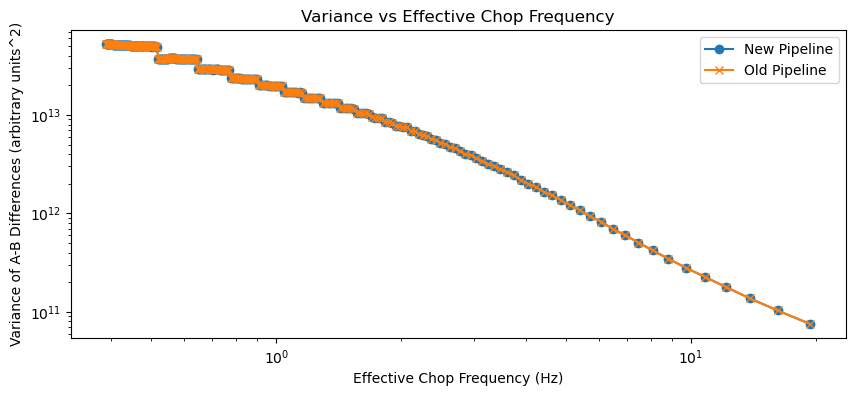

In [ ]:
# Plot 
plt.figure(figsize=(10, 4))
plt.plot(out["f_state_hz"], out["var_diff"], label="New Pipeline", marker='o')
plt.plot(old["f_eff_hz"], old["var_diff"], label="Old Pipeline", marker='x')
plt.xlabel("Effective Chop Frequency (Hz)")
plt.ylabel("Variance of A-B Differences (arbitrary units^2)")
plt.title("Variance vs Effective Chop Frequency")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()  

In [ ]:
# 1) Old pipeline
x_raw = extract_sky_timeseries(raw_cube, region=region, annulus=None, statistic="sum")["x_ap"]
old = variance_vs_frequency_chop_proxy_true(x_raw, coadds_list, frame_dt_s, method="sum", ddof=1)

# 2) New pipeline (bin images first)
new = variance_vs_frequency_from_raw_cube(
    raw_cube, coadds_list, frame_dt_s,
    region=region, annulus=None,
    statistic="sum", coadd_method="sum"
)

print("max |ratio-1|:", np.max(np.abs(new["var_diff"]/old["var_diff"] - 1)))

max |ratio-1|: 0.0


In [ ]:
# Make a list of integers for coadds 5 - 100
cadds_list = np.arange(5, 251)
#cadds_list = [6, 7, 8,9, 10,20,30, 40, 50, 60, 70, 80, 90, 100]

v2_series = variance_vs_frequency_series(
    z2['x_ap'], cadds_list, frame_dt_s=0.0113, method="mean")
v2_chop = variance_vs_frequency_chop_proxy(
    z2['x_ap'], cadds_list, frame_dt_s=0.0113, method="mean")
v3_series = variance_vs_frequency_series(
    z3['x_ap'], cadds_list, frame_dt_s=0.0113, method="mean")
v3_chop = variance_vs_frequency_chop_proxy(
    z3['x_ap'], cadds_list, frame_dt_s=0.0113, method="mean")

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(v2_series['f_eff_hz'], v2_series['var'],
         marker='o', label='Var Series')
plt.plot(v2_chop['f_eff_hz'], v2_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy')
plt.plot(v3_series['f_eff_hz'], v3_series['var'],
         marker='o', label='Var Series (Zenith 3)')
plt.plot(v3_chop['f_eff_hz'], v3_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy (Zenith 3)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")

plt.title('Variance vs Effective Frame Rate')
plt.legend()
plt.show()

In [ ]:
# Zoom in on the plot 
plt.figure(figsize=(10,4))
plt.plot(v2_series['f_eff_hz'], v2_series['var'],
         marker='o', label='Var Series')
plt.plot(v2_chop['f_eff_hz'], v2_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy')
plt.plot(v3_series['f_eff_hz'], v3_series['var'],
         marker='o', label='Var Series (Zenith 3)')
plt.plot(v3_chop['f_eff_hz'], v3_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy (Zenith 3)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
#plt.xlim(0, 7)  # Zoom in on x-axis
plt.xscale('log')
plt.title('Variance vs Effective Frame Rate (Zoomed In)')
plt.legend()

This isn't conceptually that accurate though, since you'd expect that averaging more frames (resulting in lower effective frame rates). But try using the sum instead of the average 

In [ ]:
v2_series_summed = variance_vs_frequency_series(
    z2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
v2_chop_summed = variance_vs_frequency_chop_proxy(
    z2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
v3_series_summed = variance_vs_frequency_series(
    z3['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
v3_chop_summed = variance_vs_frequency_chop_proxy(
    z3['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")


In [ ]:
plt.figure(figsize=(10,4))
# plt.plot(v2_series_summed['f_eff_hz'], v2_series_summed['var'],
#          marker='o', label='Var Series (Summed)')
plt.plot(v2_chop_summed['f_eff_hz'], v2_chop_summed['var_diff']/2,
         marker='s', label='Var Chop Proxy (Summed)')
# plt.plot(v3_series_summed['f_eff_hz'], v3_series_summed['var'],
#          marker='o', label='Var Series (Zenith 3, Summed)')
plt.plot(v3_chop_summed['f_eff_hz'], v3_chop_summed['var_diff']/2,
         marker='s', label='Var Chop Proxy (Zenith 3, Summed)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate (Summed Method)')
plt.xscale('log')
plt.legend()

# Draw a line at the 3.716 hz value in the frame rate 
plt.axvline(x=3.716, color='r', linestyle='--', label='3.716 Hz Reference')
plt.show()

In [ ]:
# Replot this in log space 
plt.figure(figsize=(10,4))
# plt.plot(v2_series_summed['f_eff_hz'], v2_series_summed['var'],
#          marker='o', label='Var Series (Summed)')
plt.plot(v2_chop_summed['f_eff_hz'], v2_chop_summed['var_diff']/2,
         marker='s', label='Var Chop Proxy (Summed)')
# plt.plot(v3_series_summed['f_eff_hz'], v3_series_summed['var'],
#          marker='o', label='Var Series (Zenith 3, Summed)')
plt.plot(v3_chop_summed['f_eff_hz'], v3_chop_summed['var_diff']/2,
         marker='s', label='Var Chop Proxy (Zenith 3, Summed)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate (Summed Method)')
plt.xscale('log')
plt.yscale('log')
plt.legend()

# Draw a line at the 3.716 hz value in the frame rate 
plt.axvline(x=3.716, color='r', linestyle='--', label='3.716 Hz Reference')
plt.show()

#### Take a look at the "long term" behavior 

In [ ]:
# Get a PSD of the time series
from scipy.signal import welch
f2, Pxx2 = welch(z2['x_ap'], fs=1/0.0113, nperseg=1024)

# Other time series 
f3, Pxx3 = welch(z3['x_ap'], fs=1/0.0113, nperseg=1024)
fig, ax = plt.subplots(figsize=(10,4))
ax.loglog(f2, Pxx2, label='Zenith 2')
ax.loglog(f3, Pxx3, label='Zenith 3')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density [counts$^2$/Hz]')
ax.set_title('Power Spectral Density of Sky Level Time Series')

# Find the maximum value 
max2_index = np.argmax(Pxx2)
max2_frequency = f2[max2_index]
max2_value = Pxx2[max2_index]

max3_index = np.argmax(Pxx3)
max3_frequency = f3[max3_index]
max3_value = Pxx3[max3_index]


plt.axvline(max2_frequency, color='r', linestyle='--', label=f'Zenith 2 Peak: {max2_frequency:.3f} Hz')
plt.axvline(max3_frequency, color='g', linestyle='--', label=f'Zenith 3 Peak: {max3_frequency:.3f} Hz')
plt.legend()
plt.show()

Look at the second aperture

In [ ]:
z2_2['x_ap']

In [ ]:
z2['x_ap']

In [ ]:
v2_2_chop = variance_vs_frequency_chop_proxy(
    z2_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
v3_2_chop = variance_vs_frequency_chop_proxy(
    z3_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")

# Plot the result 
plt.figure(figsize=(10,4))
plt.plot(v2_2_chop['f_eff_hz'], v2_2_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy (Region 2, Zenith 2, Summed)')
plt.plot(v3_2_chop['f_eff_hz'], v3_2_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy (Region 2, Zenith 3, Summed)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate (Summed Method) - Region 2')
plt.xscale('log')
plt.yscale('log')
plt.legend() 
plt.show()  

Neat, and what does the PSD look like

In [ ]:
f2_2, Pxx2_2 = welch(z2_2['x_ap'], fs=1/0.0113, nperseg=1024)
f3_2, Pxx3_2 = welch(z3_2['x_ap'], fs=1/0.0113, nperseg=1024)
fig, ax = plt.subplots(figsize=(10,4))
ax.loglog(f2_2, Pxx2_2, label='Zenith 2 - Region 2')
ax.loglog(f3_2, Pxx3_2, label='Zenith 3 - Region 2')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density [counts$^2$/Hz]')
ax.set_title('Power Spectral Density of Sky Level Time Series - Region 2')      

# Find the maximum value
max2_2_index = np.argmax(Pxx2_2)
max2_2_frequency = f2_2[max2_2_index]
max2_2_value = Pxx2_2[max2_2_index]

max3_2_index = np.argmax(Pxx3_2)
max3_2_frequency = f3_2[max3_2_index]
max3_2_value = Pxx3_2[max3_2_index]

plt.axvline(max2_2_frequency, color='r', linestyle='--', label=f'Zenith 2 Peak: {max2_2_frequency:.3f} Hz')
plt.axvline(max3_2_frequency, color='g', linestyle='--', label=f'Zenith 3 Peak: {max3_2_frequency:.3f} Hz')

plt.legend()
plt.show()

## Zenith Short Exposures 

Here we test the expsoures where we have "shortened exposure time". 
We may get more impacts from things like dark current, but still should be useful for trying to test out correlated sky. 

In [ ]:
# Import the data 
zenith_SE_data = read_in_fits('./data/251227/zenith_4_se')
z4_SE = extract_sky_timeseries(zenith_SE_data, region, trim=None, annulus=None, statistic="mean")


In [ ]:
# plot the time series
plt.figure(figsize=(10,4))
plt.plot(z4_SE['x_ap'], label='Aperture Mean Sky Level (Zenith 4 SE)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith 4 SE Data')
plt.legend()
plt.show()

it looks like the "ramp down" happens faster in this series 


In [ ]:
# Reload int ghe datea taking from frame number ~400 to the end 
z4_SE_clipped = extract_sky_timeseries(zenith_SE_data, region, trim=(400, None), annulus=None, statistic="mean")

# pick new region (larger radius)
# should be double the previous area (sqrt 2 times the radius)
region2 = (30,80,30)

s4_SE_clipped_large = extract_sky_timeseries(zenith_SE_data, region2, trim=(400, None), annulus=None, statistic="mean")

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(z4_SE_clipped['x_ap'], label='Aperture Mean Sky Level (Zenith 4 SE Clipped)')
plt.plot(s4_SE_clipped_large['x_ap'], label='Aperture Mean Sky Level (Zenith 4 SE Clipped, Larger Aperture)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith 4 SE Clipped Data')
plt.legend()
plt.show()

Still a significant downturn in counts...

In [ ]:
# increase the coadds list for this data set
cadds_list = np.arange(10, 301)
z4_series = variance_vs_frequency_series(
    z4_SE_clipped['x_ap'], cadds_list, frame_dt_s=0.0053)
z4_chop = variance_vs_frequency_chop_proxy(
    z4_SE_clipped['x_ap'], cadds_list, frame_dt_s=0.0053)

z4_series_large = variance_vs_frequency_series(
    s4_SE_clipped_large['x_ap'], cadds_list, frame_dt_s=0.0053)
z4_chop_large = variance_vs_frequency_chop_proxy(
    s4_SE_clipped_large['x_ap'], cadds_list, frame_dt_s=0.0053)

In [ ]:
# plot the results 
plt.figure(figsize=(10,4))
#plt.plot(z4_series['f_eff_hz'], z4_series['var'],
#         marker='o', label='Var Series')
plt.plot(z4_chop['f_eff_hz'], z4_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy')
plt.plot(z4_chop_large['f_eff_hz'], z4_chop_large['var_diff']/2,
         marker='^', label='Var Chop Proxy (Larger Aperture)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.xlim(0, 10)
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate')
plt.legend()
plt.show()


I think this is 1/f noise - if it were sky noise, the variance would scale with Area (not sure which direction though)

Get the PSD of the  

In [ ]:
f4, Pxx4 = welch(z4_SE_clipped['x_ap'], fs=1/0.0053, nperseg=1024)
fig, ax = plt.subplots(figsize=(10,4))
ax.loglog(f4, Pxx4, label='Zenith 4 SE Clipped')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density [counts$^2$/Hz]')
ax.set_title('Power Spectral Density of Sky Level Time Series (Zenith 4 SE Clipped)')
plt.legend()
plt.show()

# High Airmass

We repeat the same analysis as above, but this time with higher airmass values. 

In [ ]:
# Read in the data from the fits files
from test_analysis import read_in_fits
ha_1_data = read_in_fits('./data/251227/highAM_1')
ha_2_data = read_in_fits('./data/251227/highAM_2')
ha_3_data = read_in_fits('./data/251227/highAM_3')
# display three random images from each to make sure it loaded in correctly
test_fig, test_axs = plt.subplots(3,3, figsize=(15,15))
for i, data in enumerate([ha_1_data, ha_2_data, ha_3_data]):
    for j in range(3):
        test_axs[j,i].imshow(data[np.random.randint(0, data.shape[0])], cmap='gray', origin='lower')
        test_axs[j,i].set_title(f'High AM {i+1} Sample {j+1}')
plt.show()


Perform aperture photometry in the same regions as before

In [ ]:
ha_1 = extract_sky_timeseries(ha_1_data, region, trim=None, annulus=None, statistic="mean")
ha_2 = extract_sky_timeseries(ha_2_data, region, trim=None, annulus=None, statistic="mean")
ha_3 = extract_sky_timeseries(ha_3_data, region, trim=None, annulus=None, statistic="mean")

ha_1_2 = extract_sky_timeseries(ha_1_data, region_2, trim=None, annulus=None, statistic="mean")
ha_2_2 = extract_sky_timeseries(ha_2_data, region_2, trim=None, annulus=None, statistic="mean")
ha_3_2 = extract_sky_timeseries(ha_3_data, region_2, trim=None, annulus=None, statistic="mean")

# plot the non-trimmed time seri
plt.figure(figsize=(10,4))
plt.plot(ha_1['x_ap'], label='Aperture Mean Sky Level (High AM 1)')
plt.plot(ha_2['x_ap'], label='Aperture Mean Sky Level (High AM 2)')
plt.plot(ha_3['x_ap'], label='Aperture Mean Sky Level (High AM 3)')

plt.plot(ha_1_2['x_ap'], label='Aperture Mean Sky Level (High AM 1) - Region 2', linestyle='--')
plt.plot(ha_2_2['x_ap'], label='Aperture Mean Sky Level (High AM 2) - Region 2', linestyle='--')
plt.plot(ha_3_2['x_ap'], label='Aperture Mean Sky Level (High AM 3) - Region 2', linestyle='--')

plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from High Airmass Data')
plt.legend()
plt.show()

In [ ]:
# Now trim the data and take the sum
ha_1 = extract_sky_timeseries(ha_1_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")
ha_2 = extract_sky_timeseries(ha_2_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")
ha_3 = extract_sky_timeseries(ha_3_data, region, trim=TRIM_FRAMES, annulus=None, statistic="sum")


# plot the trimmed time series
plt.figure(figsize=(10,4))
plt.plot(ha_1['x_ap'], label='Aperture Mean Sky Level (High AM 1)')
plt.plot(ha_2['x_ap'], label='Aperture Mean Sky Level (High AM 2)')
plt.plot(ha_3['x_ap'], label='Aperture Mean Sky Level (High AM 3)')

plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from High Airmass Data (Trimmed)')
plt.legend()
plt.show()

In [ ]:
# Now do the same with the second region
ha_1_2 = extract_sky_timeseries(ha_1_data, region_2, trim=TRIM_FRAMES, annulus=None, statistic="sum")
ha_2_2 = extract_sky_timeseries(ha_2_data, region_2, trim=TRIM_FRAMES, annulus=None, statistic="sum")
ha_3_2 = extract_sky_timeseries(ha_3_data, region_2, trim=TRIM_FRAMES, annulus=None, statistic="sum")

# plot the trimmed time series for region 2
plt.figure(figsize=(10,4))
plt.plot(ha_1_2['x_ap'], label='Aperture Mean Sky Level (High AM 1) - Region 2')
plt.plot(ha_2_2['x_ap'], label='Aperture Mean Sky Level (High AM 2) - Region 2')
plt.plot(ha_3_2['x_ap'], label='Aperture Mean Sky Level (High AM 3) - Region 2')
plt.xlabel('Frame Index')   
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from High Airmass Data (Trimmed) - Region 2')
plt.legend()
plt.show()       

interesting, the compared counts are actually lower than the zenith one... 

In [ ]:
# Use the same coadds list as before and use the sum method

ha_1_series = variance_vs_frequency_series(
    ha_1['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
ha_1_chop = variance_vs_frequency_chop_proxy(
    ha_1['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")

ha_2_series = variance_vs_frequency_series(
    ha_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
ha_2_chop = variance_vs_frequency_chop_proxy(
    ha_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")

ha_3_series = variance_vs_frequency_series(
    ha_3['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
ha_3_chop = variance_vs_frequency_chop_proxy(
    ha_3['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")  

# do the same for the other region
ha_1_2_chop = variance_vs_frequency_chop_proxy(
    ha_1_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
ha_2_2_chop = variance_vs_frequency_chop_proxy(
    ha_2_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")
ha_3_2_chop = variance_vs_frequency_chop_proxy(
    ha_3_2['x_ap'], cadds_list, frame_dt_s=0.0113, method="sum")




In [ ]:
# plot the results
plt.figure(figsize=(10,4))
plt.plot(ha_1_chop['f_eff_hz'], ha_1_chop['var_diff']/2,
         marker='s', label='High AM 1 Var Chop Proxy (Summed)')
plt.plot(ha_2_chop['f_eff_hz'], ha_2_chop['var_diff']/2,
         marker='^', label='High AM 2 Var Chop Proxy (Summed)')
plt.plot(ha_3_chop['f_eff_hz'], ha_3_chop['var_diff']/2,
         marker='o', label='High AM 3 Var Chop Proxy (Summed)')

# Overplot region 2 results 
plt.plot(ha_1_2_chop['f_eff_hz'], ha_1_2_chop['var_diff']/2,
         marker='s', linestyle='--', label='High AM 1 Var Chop Proxy (Region 2, Summed)')
plt.plot(ha_2_2_chop['f_eff_hz'], ha_2_2_chop['var_diff']/2,
         marker='^', linestyle='--', label='High AM 2 Var Chop Proxy (Region 2, Summed)')
plt.plot(ha_3_2_chop['f_eff_hz'], ha_3_2_chop['var_diff']/2,
         marker='o', linestyle='--', label='High AM 3 Var Chop Proxy (Region 2, Summed)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate for High Airmass Data (Summed Method)')
plt.legend()
plt.show()

PSD of time series 

In [ ]:
p_ha_1, Pxx_ha_1 = welch(ha_1['x_ap'], fs=1/0.0113, nperseg=1024)
p_ha_2, Pxx_ha_2 = welch(ha_2['x_ap'], fs=1/0.0113, nperseg=1024)   
p_ha_3, Pxx_ha_3 = welch(ha_3['x_ap'], fs=1/0.0113, nperseg=1024)
fig, ax = plt.subplots(figsize=(10,4))
ax.loglog(p_ha_1, Pxx_ha_1, label='High AM 1')
ax.loglog(p_ha_2, Pxx_ha_2, label='High AM 2')
ax.loglog(p_ha_3, Pxx_ha_3, label='High AM 3')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density [counts$^2$/Hz]')
ax.set_title('Power Spectral Density of Sky Level Time Series (High Airmass)')
plt.legend()

# find the maximum value 
max_ha_1_index = np.argmax(Pxx_ha_1)
max_ha_1_frequency = p_ha_1[max_ha_1_index]
max_ha_1_value = Pxx_ha_1[max_ha_1_index]

max_ha_2_index = np.argmax(Pxx_ha_2)
max_ha_2_frequency = p_ha_2[max_ha_2_index]
max_ha_2_value = Pxx_ha_2[max_ha_2_index]

max_ha_3_index = np.argmax(Pxx_ha_3)
max_ha_3_frequency = p_ha_3[max_ha_3_index]
max_ha_3_value = Pxx_ha_3[max_ha_3_index]   

plt.axvline(max_ha_1_frequency, color='r', linestyle='--', label=f'High AM 1 Peak: {max_ha_1_frequency:.3f} Hz')
plt.axvline(max_ha_2_frequency, color='g', linestyle='--', label=f'High AM 2 Peak: {max_ha_2_frequency:.3f} Hz')
plt.axvline(max_ha_3_frequency, color='b', linestyle='--', label=f'High AM 3 Peak: {max_ha_3_frequency:.3f} Hz')
plt.legend()    
plt.show()

In [ ]:
# combine all profiles for region 1 
plt.figure(figsize=(10,4))
plt.plot(v2_chop_summed['f_eff_hz'], v2_chop_summed['var_diff']/2,
         marker='o', label='Zenith 2')
plt.plot(v3_chop_summed['f_eff_hz'], v3_chop_summed['var_diff']/2,
         marker='s', label='Zenith 3')
plt.plot(ha_1_chop['f_eff_hz'], ha_1_chop['var_diff']/2,
         marker='^', label='High AM 1')
plt.plot(ha_2_chop['f_eff_hz'], ha_2_chop['var_diff']/2,
         marker='v', label='High AM 2')
plt.plot(ha_3_chop['f_eff_hz'], ha_3_chop['var_diff']/2,
         marker='x', label='High AM 3')
plt.xlabel('Effective Frame Rate (Hz)')
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate Comparison Region 1')
plt.legend()
plt.show()  

In [ ]:
# combine the data from region 2 
plt.figure(figsize=(10,4))
plt.plot(v2_2_chop['f_eff_hz'], v2_2_chop['var_diff']/2,
         marker='o', label='Zenith 2 - Region 2')
plt.plot(v3_2_chop['f_eff_hz'], v3_2_chop['var_diff']/2,
         marker='s', label='Zenith 3') 
plt.plot(ha_1_2_chop['f_eff_hz'], ha_1_2_chop['var_diff']/2,
         marker='^', label='High AM 1 - Region 2')
plt.plot(ha_2_2_chop['f_eff_hz'], ha_2_2_chop['var_diff']/2,
         marker='v', label='High AM 2 - Region 2')
plt.plot(ha_3_2_chop['f_eff_hz'], ha_3_2_chop['var_diff']/2,
         marker='x', label='High AM 3 - Region 2')

plt.xlabel('Effective Frame Rate (Hz)')
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate Comparison Region 2')
plt.legend()
plt.show()  

In [ ]:
# Plot the region and photometry results 
apertures = CircularAperture((region[1], region[0]), r=region[2])
fig, ax = plt.subplots(3,2, figsize=(12,18))
for i, (data, phot, title) in enumerate(zip([zenith_1_data, zenith_2_data, zenith_3_data],
                                           [zenith_1_phot, zenith_2_phot, zenith_3_phot],
                                           ['Zenith 1', 'Zenith 2', 'Zenith 3'])):
    ax[i,0].imshow(data[0], cmap='gray', origin='lower')
    apertures.plot(ax[i,0], color='red', lw=2)
    ax[i,0].set_title(f'{title} - Sample Image with Aperture')
    
    ax[i,1].plot(phot['aperture_sum'], marker='o')
    ax[i,1].set_title(f'{title} - Aperture Photometry Over Time')
    ax[i,1].set_xlabel('Frame index')
    ax[i,1].set_ylabel('Aperture Sum')
    # Twin y to plot variance 
    ax2 = ax[i,1].twinx()
    ax2.plot(phot['aperture_var'], marker='x', color='blue')
    ax2.set_ylabel('Aperture Variance', color='blue')
plt.tight_layout()
plt.show()


I think something went wrong with the first exposure sequence. The other two look okay though - very interesting that there is an increase in the signal (we saw a decrease the last time) 

Cut the first 150 frames out of the sequence    

In [ ]:
# Coadd the frames and see what you end up with 
import numpy as np

def coadd_exposures(exposure_sequence, coadds, mode="average", dtype=np.float32):
    """
    Coadd frames in non-overlapping blocks of size `coadds`.
    Returns array (n_blocks, H, W).
    """
    if coadds < 1:
        raise ValueError("coadds must be >= 1")

    n, H, W = exposure_sequence.shape
    n_use = (n // coadds) * coadds
    if n_use < coadds:
        raise ValueError(f"Not enough frames ({n}) for coadds={coadds}")

    blocks = exposure_sequence[:n_use].reshape(n_use // coadds, coadds, H, W)

    if mode == "average":
        out = blocks.mean(axis=1, dtype=np.float64)
    elif mode == "sum":
        out = blocks.sum(axis=1, dtype=np.float64)
    elif mode == "sum_normalized":
        out = blocks.sum(axis=1, dtype=np.float64) / coadds
    else:
        raise ValueError("mode must be 'average', 'sum', or 'sum_normalized'")

    return out.astype(dtype, copy=False)


def _compute_variances_from_series(x, use_differences=True, ddof=1):
    """
    Returns (var_series, var_diff, n_series, n_diff)
    """
    x = np.asarray(x, dtype=float)
    v_series = np.var(x, ddof=ddof)
    n_series = x.size

    if use_differences:
        dx = np.diff(x)
        v_diff = np.var(dx, ddof=ddof)
        n_diff = dx.size
    else:
        v_diff = np.nan
        n_diff = 0

    return v_series, v_diff, n_series, n_diff


# -------------------------
# A) FIXED TOTAL RAW FRAMES
# -------------------------
def variance_vs_coadds_fixed_total_frames(
    exposure_sequence,
    coadds_list,
    stat_fn,
    n_frames_total=None,
    mode="average",
    use_differences=True,
    ddof=1,
):
    """
    Option A: Fix the total number of raw frames used for every coadds
    (fixed time baseline). The number of coadded samples varies with coadds.

    Parameters
    ----------
    n_frames_total : int or None
        If None, uses all frames in exposure_sequence. If provided, uses the first
        n_frames_total frames (trimmed down further to a multiple of coadds).

    Returns
    -------
    dict with arrays:
      coadds, n_frames_used, n_blocks_used, n_series, n_diff, var_series, var_diff
    """
    n_all = exposure_sequence.shape[0]
    if n_frames_total is None:
        n_frames_total = n_all
    n_frames_total = min(n_frames_total, n_all)

    out = {k: [] for k in [
        "coadds", "n_frames_used", "n_blocks_used", "n_series", "n_diff", "var_series", "var_diff"
    ]}

    base = exposure_sequence[:n_frames_total]

    for c in coadds_list:
        n_use = (base.shape[0] // c) * c
        if n_use < 2 * c:
            # need at least 2 coadded points if using differences
            continue

        seq = base[:n_use]
        coadded = coadd_exposures(seq, coadds=c, mode=mode)

        x = np.array([stat_fn(im) for im in coadded], dtype=float)
        v_series, v_diff, n_series, n_diff = _compute_variances_from_series(
            x, use_differences=use_differences, ddof=ddof
        )

        out["coadds"].append(c)
        out["n_frames_used"].append(n_use)
        out["n_blocks_used"].append(coadded.shape[0])
        out["n_series"].append(n_series)
        out["n_diff"].append(n_diff)
        out["var_series"].append(v_series)
        out["var_diff"].append(v_diff)

    return {k: np.array(v) for k, v in out.items()}


# ----------------------------
# B) FIXED # COADDED SAMPLES
# ----------------------------
def variance_vs_coadds_fixed_n_blocks(
    exposure_sequence,
    coadds_list,
    stat_fn,
    n_blocks=200,
    mode="average",
    use_differences=True,
    ddof=1,
):
    """
    Option B: Fix the number of coadded samples used in the variance estimate
    (constant estimator sample size). Total raw frames used grows with coadds.

    Uses exactly n_blocks * coadds frames when possible; otherwise uses the maximum
    full blocks available and reports n_blocks_used.

    Returns
    -------
    dict with arrays:
      coadds, n_frames_used, n_blocks_used, n_series, n_diff, var_series, var_diff
    """
    n_all = exposure_sequence.shape[0]
    out = {k: [] for k in [
        "coadds", "n_frames_used", "n_blocks_used", "n_series", "n_diff", "var_series", "var_diff"
    ]}

    for c in coadds_list:
        frames_needed = n_blocks * c

        if n_all >= frames_needed:
            n_use = frames_needed
            nb_used = n_blocks
        else:
            nb_used = n_all // c
            n_use = nb_used * c

        if nb_used < 2:
            continue

        seq = exposure_sequence[:n_use]
        coadded = coadd_exposures(seq, coadds=c, mode=mode)

        x = np.array([stat_fn(im) for im in coadded], dtype=float)
        v_series, v_diff, n_series, n_diff = _compute_variances_from_series(
            x, use_differences=use_differences, ddof=ddof
        )

        out["coadds"].append(c)
        out["n_frames_used"].append(n_use)
        out["n_blocks_used"].append(nb_used)
        out["n_series"].append(n_series)
        out["n_diff"].append(n_diff)
        out["var_series"].append(v_series)
        out["var_diff"].append(v_diff)

    return {k: np.array(v) for k, v in out.items()}


# -------------------------
# Convenience: effective Hz
# -------------------------
def add_effective_frequency(results, frame_rate_hz):
    """
    Adds f_eff = frame_rate_hz / coadds to a results dict (returns a copy).
    """
    out = dict(results)
    out["f_eff_hz"] = frame_rate_hz / out["coadds"]
    return out


In [ ]:
from photutils.aperture import CircularAperture, aperture_photometry

ap = CircularAperture((region[1], region[0]), r=region[2])
ap_area = ap.area

def stat_fn(image):
    tbl = aperture_photometry(image, ap)
    return float(tbl["aperture_sum"][0] / ap_area)  # mean in aperture


In [ ]:
coadds_list = [1, 2, 3, 5, 6,  7, 8,9,10]
frame_rate_hz = CHAR_FREQ = 1/0.0113

res_A = variance_vs_coadds_fixed_total_frames(
    zenith_2_data,
    coadds_list,
    stat_fn,
    n_frames_total=1350,   # or None for all
    mode="average",
    use_differences=True
)

res_B = variance_vs_coadds_fixed_n_blocks(
    zenith_2_data,
    coadds_list,
    stat_fn,
    n_blocks=100,
    mode="average",
    use_differences=True
)

res_A = add_effective_frequency(res_A, frame_rate_hz)
res_B = add_effective_frequency(res_B, frame_rate_hz)


In [ ]:
res_A,

In [ ]:
res_B

In [ ]:
# plot the f_eff_hz vs the variance results
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].plot(res_A['f_eff_hz'], res_A['var_series'],
            marker='o', label='Var Series')
ax[0].set_xlabel('Effective Frame Rate (Hz)')
ax[0].set_ylabel('Variance of Aperture Mean')
ax[0].set_title('Fixed Total Raw Frames')   

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[1].plot(res_B['f_eff_hz'], res_B['var_series'],
            marker='o', label='Var Series', color='orange')
ax[1].set_xlabel('Effective Frame Rate (Hz)')
ax[1].set_ylabel('Variance of Aperture Mean')
ax[1].set_title('Fixed # Coadded Samples')
plt.show()